# GPT TTS

In [23]:
from focalcodec.codec import FocalCodec
from pathlib import Path
import torch
import soundfile as sf
import torchaudio
import numpy as np
import librosa
import matplotlib.pyplot as plt
import pandas as pd
import os
from tqdm.auto import tqdm
from transformers import GPT2TokenizerFast

DATA = Path("data")
LJSPEECH = DATA / "LJSpeech-1.1"
PONY = DATA / "pony-speech"
LLM = DATA / "llm"
IMG = Path("img")

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
device

'mps'

In [5]:
codec = FocalCodec.from_pretrained('lucadellalib/focalcodec_25hz')
codec.to(device)
codec.eval()

for p in codec.parameters():
  p.requires_grad_(False)

codec

FocalCodec(
  (encoder): WavLM(
    (feature_extractor): FeatureExtractor(
      (layers): ModuleList(
        (0): ConvBlock(
          (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,), bias=False)
          (dropout): Dropout(p=0.0, inplace=False)
          (norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation): GELU(approximate='none')
        )
        (1-4): 4 x ConvBlock(
          (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,), bias=False)
          (dropout): Dropout(p=0.0, inplace=False)
          (norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation): GELU(approximate='none')
        )
        (5-6): 2 x ConvBlock(
          (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,), bias=False)
          (dropout): Dropout(p=0.0, inplace=False)
          (norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation): GELU(approximate='none')
        )
      )
    )
    (norm): LayerNor

In [6]:
CODEBOOK_SIZE = int(codec.codebook.shape[0])
CODEC_SR = codec.sample_rate_input

print(f'codebook={CODEBOOK_SIZE}, sr_in/out={CODEC_SR}/{codec.sample_rate_output}')

codebook=8192, sr_in/out=16000/16000


In [13]:
def load_wav_16k(path):
  arr, sr = sf.read(path, dtype='float32', always_2d=False)

  if arr.ndim > 1:
    arr = arr.mean(-1)

  wav = torch.from_numpy(arr)

  if sr != CODEC_SR:
    wav = torchaudio.functional.resample(wav, sr, CODEC_SR)

  return wav

def plot_mel(wav, sr, title=''):
  wav = np.asarray(wav).astype(np.float32)

  if wav.ndim > 1:
    wav = wav.mean(0)

  S = librosa.feature.melspectrogram(
    y=wav, sr=sr, n_fft=1024, hop_length=256,
    n_mels=80, fmin=50, fmax=sr//2
  )

  _, ax = plt.subplots(figsize=(max(6, len(wav)/sr*1.2), 3))

  librosa.display.specshow(
    librosa.power_to_db(S, ref=np.max),
    sr=sr, hop_length=256,
    x_axis='time', y_axis='mel',
    ax=ax
  )
  ax.set_title(title, fontsize=9)
  plt.show()

In [15]:
train = pd.read_parquet(LJSPEECH / "train.parquet")
test = pd.read_parquet(LJSPEECH / "test.parquet")
val = pd.read_parquet(LJSPEECH / "val.parquet")

/Users/alegator1209/micromamba/envs/deep-audio/lib/python3.11/site-packages/focalcodec/vocos.py:285: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [1, 1024, 372]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runnerx/miniforge3/conda-bld/libtorch_1770196967836/work/aten/src/ATen/native/Resize.cpp:38.)
  ifft = torch.fft.irfft(input, self.n_fft, dim=1, norm="backward")


LJ032-0164: 7.43s -> 186 tokens


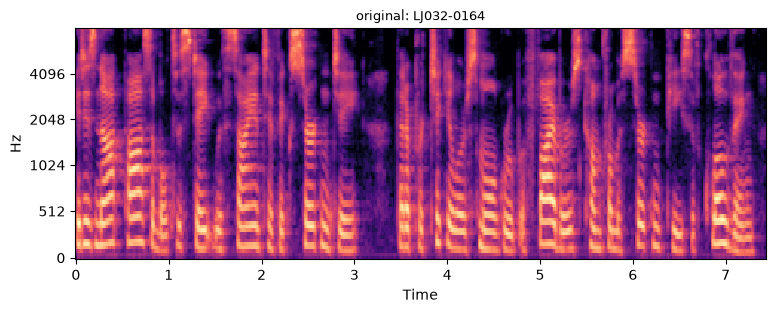

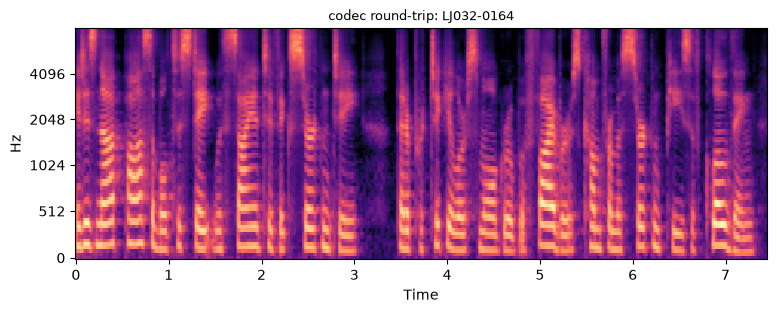

In [19]:
row = val.iloc[0]
wav = load_wav_16k(row['path']).to(device)

with torch.no_grad():
  toks = codec.sig_to_toks(wav.unsqueeze(0))
  rec = codec.toks_to_sig(toks).squeeze(0).detach().cpu().numpy()

print(f'{row["file"]}: {wav.shape[-1]/CODEC_SR:.2f}s -> {toks.shape[-1]} tokens')
plot_mel(wav.cpu().numpy(), CODEC_SR, f'original: {row["file"]}')
plot_mel(rec, codec.sample_rate_output, f'codec round-trip: {row["file"]}')

In [21]:
tokenizer = GPT2TokenizerFast.from_pretrained('gpt2')

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [ ]:
@torch.no_grad()
def encode_split(df, cache_path, batch_size=16, overwrite=False):
  if cache_path.exists() and not overwrite:
    print(f'load cache: {cache_path}')
    return torch.load(cache_path, weights_only=False)

  df['normalized_text'] = df['normalized_text'].fillna(df['text'])

  recs = df.to_dict('records')
  paths = [r['path'] for r in recs]
  order = np.argsort([os.path.getsize(p) for p in paths])
  out = [None] * len(recs)

  for start in tqdm(range(0, len(recs), batch_size)):
    idxs = order[start:start+batch_size]
    wavs = [load_wav_16k(paths[i]) for i in idxs]
    lengths = torch.tensor([w.numel() for w in wavs], dtype=torch.float32)

    L = int(lengths.max())
    batch = torch.zeros(len(wavs), L)

    for j, w in enumerate(wavs):
      batch[j, :w.numel()] = w

    batch = batch.to(device)
    rel_lengths = (lengths/L).to(device)
    toks = codec.sig_to_toks(batch, length=rel_lengths)
    tok_lens = (rel_lengths * toks.shape[-1]).round().clamp(max=toks.shape[-1]).to(torch.long)

    for j, i in enumerate(idxs):
      text_ids = tokenizer.encode(recs[i]['normalized_text'], add_special_tokens=False)
      text_ids = torch.tensor(text_ids, dtype=torch.long)
      audio_ids = toks[j, :tok_lens[j]].to(torch.long).cpu()
      out[i] = {
          'file': recs[i]['file'],
          'text': recs[i]['normalized_text'],
          'text_ids': text_ids,
          'audio_ids': audio_ids,
          'n_text': int(text_ids.numel()),
          'n_audio': int(audio_ids.numel()),
      }

  if not cache_path.parent.exists():
    cache_path.parent.mkdir()

  torch.save(out, cache_path)
  print(f'saved {len(out)} items to {cache_path}')
  return out


In [ ]:
train_items = encode_split(train, LJSPEECH / "tokenized" / "train.pt")
test_items = encode_split(test, LJSPEECH / "tokenized" / "test.pt")
val_items = encode_split(val, LJSPEECH / "tokenized" / "val.pt")

a = np.array([r['n_audio'] for r in train_items])
t = np.array([r['n_text']  for r in train_items])

print(f'audio tokens: mean={a.mean():.1f} p95={np.percentile(a,95):.0f} max={a.max()}')
print(f'text  tokens: mean={t.mean():.1f} p95={np.percentile(t,95):.0f} max={t.max()}')

  0%|          | 0/664 [00:00<?, ?it/s]